In [2]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [8]:
# データ前処理（リサイズ＋テンソル化）
transform = transforms.Compose([
    transforms.Resize((224, 224)),     # サイズ統一
    transforms.ToTensor(),             # PyTorchテンソルに変換
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # 任意：正規化（白黒なら1ch、カラーなら3chにする）
])

In [9]:
'''
３：ImageFolderで読み込み（全体）
'''
#data/all ディレクトリを走査し、サブフォルダ名（クラス名）ごとに画像を分類する
#各画像は transform で前処理されて dataset に格納される
dataset = datasets.ImageFolder("data/all", transform=transform)

#各クラス名に自動で割り振られたインデックス（ラベル）を確認
print("クラス名とインデックス:", dataset.class_to_idx)  # 例: {'all_benign': 0, 'all_early': 1, ...}

クラス名とインデックス: {'all_benign': 0, 'all_early': 1, 'all_pre': 2, 'all_pro': 3}


In [5]:
'''
４：train / val / test に分割
'''
from torch.utils.data import random_split

total_size = len(dataset)#データ全体の枚数（画像枚数）を取得
train_size = int(0.7 * total_size)#訓練データ：70%
val_size = int(0.15 * total_size)#検証データ：15%
test_size = total_size - train_size - val_size#残り：テストデータ：15%

#ランダムに分割して、それぞれを新しいデータセットとして取得
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

In [10]:
'''
５：DataLoader を作成
'''
#学習用データを32枚ずつランダムにシャッフルして供給する
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

##検証・テストはシャッフル不要（評価の一貫性を保つため）
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

画像の形: torch.Size([32, 3, 224, 224])
ラベル: tensor([1, 1, 3, 3, 3, 1, 3, 3, 1, 3])


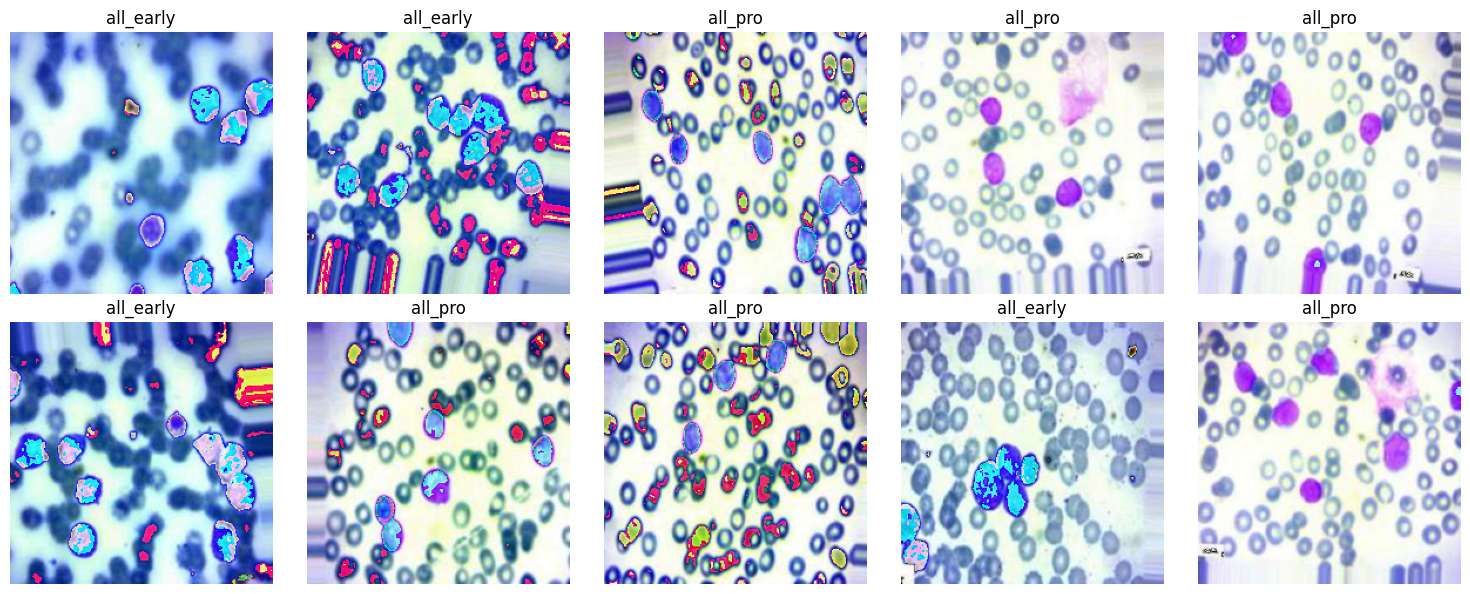

In [11]:
'''
６：データの確認
'''
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms.functional as F

# クラス名の辞書を取得（例：{0: 'all_benign', 1: 'all_early', ...}）
idx_to_class = {v: k for k, v in dataset.class_to_idx.items()}
#train_loader から1バッチ分（32枚）を取り出す
images, labels = next(iter(train_loader))

#出力例：torch.Size([32, 3, 224, 224])
#意味：バッチサイズ32、カラー画像3チャンネル、高さ224、幅224
print("画像の形:", images.shape)   

#最初の10個の画像に対応するクラスラベルを表示（例：tensor([1, 0, 3, 2, ...])）
print("ラベル:", labels[:10])     # 最初の10個のラベル

# 最初の10枚を表示
plt.figure(figsize=(15, 6))
for i in range(10):
    img = images[i]  # テンソル画像（C, H, W）
    label = labels[i].item()

    # PyTorchテンソルをPIL画像に戻す（表示のため）
    img = F.to_pil_image(img)

    # 画像をプロット
    plt.subplot(2, 5, i+1)
    plt.imshow(img)
    plt.title(idx_to_class[label])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=4):  # ← クラス数に応じて設定
        super(SimpleCNN, self).__init__()

        # 畳み込み層1：入力チャンネル3（RGB）、出力チャンネル16、カーネルサイズ3
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)  # プーリング層（共通）

        # 畳み込み層2：入力16 → 出力32
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)

        # 畳み込み層3：32 → 64
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)

        # 全結合層（224 → 112 → 56 → 28 → flatten）
        self.fc1 = nn.Linear(64 * 28 * 28, 256)
        self.fc2 = nn.Linear(256, num_classes)  # ← 最後はクラス数に対応

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # conv1 + ReLU + pool
        x = self.pool(F.relu(self.conv2(x)))  # conv2 + ReLU + pool
        x = self.pool(F.relu(self.conv3(x)))  # conv3 + ReLU + pool
        x = x.view(x.size(0), -1)             # flatten（バッチ数, 特徴量）
        x = F.relu(self.fc1(x))               # 全結合層1 + ReLU
        x = self.fc2(x)                       # 出力層（ロジット）
        return x

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# モデルの準備（前提：SimpleCNNが定義済み）
model = SimpleCNN(num_classes=4).to(device)

# 損失関数（多クラス分類にはCrossEntropyLoss）
criterion = nn.CrossEntropyLoss()

# 最適化手法（ここではAdam）
optimizer = optim.Adam(model.parameters(), lr=0.001)

# エポック数
num_epochs = 10

for epoch in range(num_epochs):
    print(f"\n--- Epoch {epoch+1}/{num_epochs} ---")
    
    # ----- 学習モード -----
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # 勾配を初期化
        optimizer.zero_grad()

        # 順伝播
        outputs = model(images)

        # 損失計算
        loss = criterion(outputs, labels)

        # 逆伝播
        loss.backward()
        optimizer.step()

        # 統計記録
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / total
    train_acc = correct / total
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")

    # ----- 検証モード -----
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss /= val_total
    val_acc = val_correct / val_total
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")


--- Epoch 1/10 ---
Train Loss: 0.3657, Train Acc: 0.8546
Val Loss: 0.1257, Val Acc: 0.9517

--- Epoch 2/10 ---
Train Loss: 0.0620, Train Acc: 0.9781
Val Loss: 0.0419, Val Acc: 0.9847

--- Epoch 3/10 ---
Train Loss: 0.0357, Train Acc: 0.9878
Val Loss: 0.0240, Val Acc: 0.9910

--- Epoch 4/10 ---
Train Loss: 0.0076, Train Acc: 0.9974
Val Loss: 0.0236, Val Acc: 0.9920

--- Epoch 5/10 ---
Train Loss: 0.0343, Train Acc: 0.9896
Val Loss: 0.0206, Val Acc: 0.9943

--- Epoch 6/10 ---
Train Loss: 0.0131, Train Acc: 0.9959
Val Loss: 0.0515, Val Acc: 0.9827

--- Epoch 7/10 ---
Train Loss: 0.0016, Train Acc: 0.9997
Val Loss: 0.0170, Val Acc: 0.9943

--- Epoch 8/10 ---
Train Loss: 0.0001, Train Acc: 1.0000
Val Loss: 0.0152, Val Acc: 0.9947

--- Epoch 9/10 ---
Train Loss: 0.0000, Train Acc: 1.0000
Val Loss: 0.0161, Val Acc: 0.9947

--- Epoch 10/10 ---
Train Loss: 0.0000, Train Acc: 1.0000
Val Loss: 0.0156, Val Acc: 0.9947



Classification Report:

              precision    recall  f1-score   support

  all_benign       1.00      0.99      0.99       730
   all_early       0.99      1.00      1.00       724
     all_pre       1.00      1.00      1.00       758
     all_pro       1.00      1.00      1.00       788

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



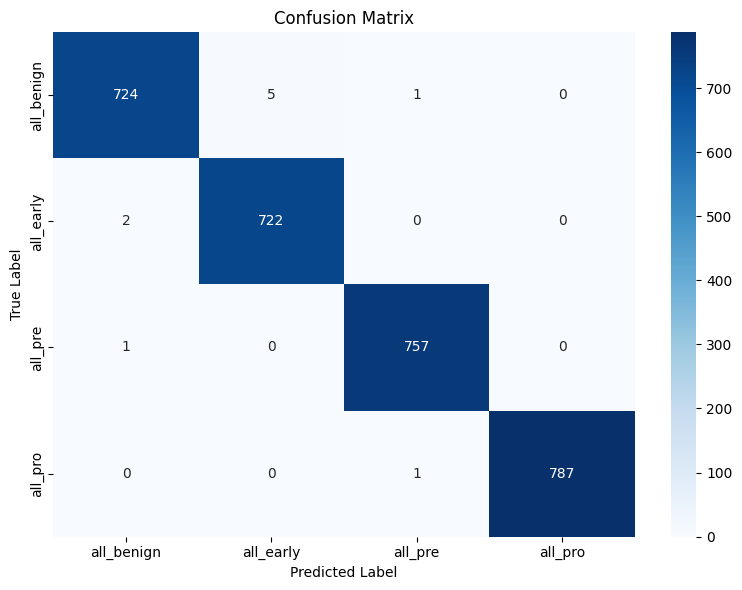

In [22]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 評価モードへ切り替え
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# ラベル名を取得
class_names = list(dataset.class_to_idx.keys())

# 混同行列の作成
cm = confusion_matrix(all_labels, all_preds)
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=class_names))

# 混同行列の可視化
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

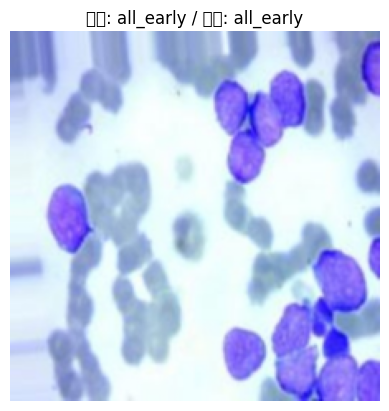

In [64]:
import random
import matplotlib.pyplot as plt
import torch
import torchvision.transforms as transforms

# クラス名の取得（例: {'all_benign': 0, ...} を ['all_benign', ...] に）
idx_to_class = {v: k for k, v in dataset.class_to_idx.items()}

# モデルを評価モードに
model.eval()

# ランダムに1枚取り出す
sample_idx = random.randint(0, len(test_dataset) - 1)
image, label = test_dataset[sample_idx]

# バッチ次元を追加してGPU or CPUへ
input_tensor = image.unsqueeze(0).to(device)

# 予測を実行
with torch.no_grad():
    output = model(input_tensor)
    _, predicted = torch.max(output, 1)

# 予測・正解クラス名取得
predicted_class = idx_to_class[predicted.item()]
true_class = idx_to_class[label]

# 画像を表示（Normalizeを元に戻す）
image_np = image.permute(1, 2, 0).cpu().numpy()  # C×H×W → H×W×C
image_np = (image_np * 0.5) + 0.5                # Normalize解除

plt.imshow(image_np)
plt.title(f"予測: {predicted_class} / 正解: {true_class}")
plt.axis('off')
plt.show()

In [65]:
torch.save(model.state_dict(), "cnn_cancer_model.pth")
print("モデルを保存しました。")

モデルを保存しました。
